load dataset

In [22]:
from datasets import load_dataset

dataset = load_dataset("sitloboi2012/rvl_cdip_large_dataset")

c:\Users\komet\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checking if dataset is available

In [23]:
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 30400
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3200
    })
    validate: Dataset({
        features: ['image', 'label'],
        num_rows: 3200
    })
})
{'image': <PIL.Image.Image image mode=L size=762x1000 at 0x1B09A34EE90>, 'label': 0}


Saving dataset in respective folders. In train, validate and test

In [ ]:
#function to save images
def save_dataset_split(dataset_split, split_name, base_path="documents"):
    import os
    #create folder
    split_dir = os.path.join(base_path, split_name)
    os.makedirs(split_dir, exist_ok=True)
    #loop through data set
    for example in dataset_split:
        #get label (class)
        label_name = dataset_split.features["label"].int2str(example["label"])
        #creat subfolder
        label_dir = os.path.join(split_dir, label_name)
        os.makedirs(label_dir, exist_ok=True)
        #count how many images exist in folder
        img_count = len(os.listdir(label_dir))
        #save image with unique name
        example["image"].save(os.path.join(label_dir, f"{img_count}.png"))

# Usage:
save_dataset_split(dataset["train"], "train")
save_dataset_split(dataset["validate"], "validate")
save_dataset_split(dataset["test"], "test")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from pathlib import Path
from tensorflow.keras.applications import EfficientNetB0

equate pixels and batch size

In [77]:
IMG_SIZE = (224, 224)
batch_size = 32

create data generators for training, validation and test datasets

In [78]:
train_dataGenerator = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.05,
    rotation_range=3
)

validation_dataGenerator = ImageDataGenerator(rescale=1./255)
test_dataGenerator = ImageDataGenerator(rescale=1./255)


get path of current directory

In [79]:
file_path = Path.cwd()
datasets_directory = file_path / "documents"

Load images from their resptive directories 

In [ ]:

trainDatasets = train_dataGenerator.flow_from_directory(
    datasets_directory / "train",
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode="categorical"
)

validationDatasets = validation_dataGenerator.flow_from_directory(
    datasets_directory / "validate",
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode="categorical"
)
testDatasets = test_dataGenerator.flow_from_directory(
    datasets_directory / "test",
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False 
)

Found 30400 images belonging to 16 classes.
Found 3200 images belonging to 16 classes.
Found 3200 images belonging to 16 classes.


print the number of samples in each dataset

In [81]:
classSamplesT = trainDatasets.samples
classSamplesV = validationDatasets.samples
classSamplesTest = testDatasets.samples

print("Training samples:", classSamplesT)
print("Validation samples:", classSamplesV)
print("Test samples:", classSamplesTest)

Training samples: 30400
Validation samples: 3200
Test samples: 3200


Displaying all labels in the datasets

In [82]:
print(trainDatasets.class_indices)
print(validationDatasets.class_indices)

{'advertisement': 0, 'budget': 1, 'email': 2, 'file folder': 3, 'form': 4, 'handwritten': 5, 'invoice': 6, 'letter': 7, 'memo': 8, 'news article': 9, 'presentation': 10, 'questionnaire': 11, 'resume': 12, 'scientific publication': 13, 'scientific report': 14, 'specification': 15}
{'advertisement': 0, 'budget': 1, 'email': 2, 'file folder': 3, 'form': 4, 'handwritten': 5, 'invoice': 6, 'letter': 7, 'memo': 8, 'news article': 9, 'presentation': 10, 'questionnaire': 11, 'resume': 12, 'scientific publication': 13, 'scientific report': 14, 'specification': 15}


Creating the MobileNetV2 model along with 3 dense layers and one output layer containing 16 neurons

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Strong classifier head
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
# second layer
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
# third layer 
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
#output layer 
output = Dense(16, activation='softmax')(x)
#combine everything 
model = tf.keras.Model(inputs=base_model.input, outputs=output)

9406464/9406464 [==============================] - 0s 0us/step


Compiling model using adam optimizer 

In [85]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Creating modelCheck point is to prevent loosing best model, and Early stopping to stop early after  3 bad epochs. Callback is also initialized 

In [86]:
weghtPath = "best_weights.weights.h5"

checkPoint = ModelCheckpoint(
    weghtPath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

callbacks = [checkPoint, early_stop]

Fit model, with maximum training of 30 epochs and callback controlling early termination

In [87]:
history = model.fit(
    trainDatasets,
    validation_data=validationDatasets,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
950/950 [==============================] - ETA: 0s - loss: 2.2598 - accuracy: 0.2911
Epoch 1: val_accuracy improved from -inf to 0.45812, saving model to best_weights.weights.h5
950/950 [==============================] - 504s 528ms/step - loss: 2.2598 - accuracy: 0.2911 - val_loss: 1.7891 - val_accuracy: 0.4581
Epoch 2/30
950/950 [==============================] - ETA: 0s - loss: 1.8188 - accuracy: 0.4337
Epoch 2: val_accuracy improved from 0.45812 to 0.50969, saving model to best_weights.weights.h5
950/950 [==============================] - 440s 463ms/step - loss: 1.8188 - accuracy: 0.4337 - val_loss: 1.6151 - val_accuracy: 0.5097
Epoch 3/30
950/950 [==============================] - ETA: 0s - loss: 1.6728 - accuracy: 0.4818
Epoch 3: val_accuracy improved from 0.50969 to 0.52406, saving model to best_weights.weights.h5
950/950 [==============================] - 542s 571ms/step - loss: 1.6728 - accuracy: 0.4818 - val_loss: 1.5457 - val_accuracy: 0.5241
Epoch 4/30
950/950 [==

load best model and evaluate model with test dataset

In [98]:
model.load_weights("best_weights.weights.h5")
loss, accuracy = model.evaluate(testDatasets)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

100/100 [==============================] - 23s 233ms/step - loss: 1.3049 - accuracy: 0.6078
Validation Loss: 1.3049137592315674
Validation Accuracy: 0.6078125238418579


predicting a single image called test.jpg

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load image
img = image.load_img("test.jpg", target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get class index
predicted_class_index = np.argmax(prediction)

# Map to label
class_labels = list(trainDatasets.class_indices.keys())

print("Predicted class:", class_labels[predicted_class_index])

1/1 [==============================] - 1s 667ms/step
Predicted class: email


Generating the precision, recall, F1-score and support of each category

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
#reset generator
testDatasets.reset()
#make prediction
predictions = model.predict(testDatasets)
#convert probabilities 
predicted_classes = np.argmax(predictions, axis=1)
#get true labels 
true_classes = testDatasets.classes
#get class names
class_labels = list(testDatasets.class_indices.keys())
# print report 
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

100/100 [==============================] - 24s 234ms/step
                        precision    recall  f1-score   support

         advertisement       0.85      0.73      0.79       200
                budget       0.58      0.48      0.53       200
                 email       0.84      0.83      0.84       200
           file folder       0.76      0.90      0.82       200
                  form       0.46      0.41      0.43       200
           handwritten       0.55      0.90      0.68       200
               invoice       0.61      0.46      0.52       200
                letter       0.44      0.54      0.48       200
                  memo       0.31      0.42      0.36       200
          news article       0.77      0.69      0.73       200
          presentation       0.56      0.58      0.57       200
         questionnaire       0.50      0.40      0.44       200
                resume       0.73      0.65      0.69       200
scientific publication       0.65      0.83  

High-performing classes such as email (F1-score: 0.84), file folder (0.82), and advertisement (0.79) were classified accurately due to their distinct visual structures. In contrast, classes such as memo (0.36), scientific report (0.32), and form (0.43) showed significantly lower performance. Model seems to struggle with structurally similar or text-heavy categories

load confusing matrix

In [105]:
cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[146   0   1   4   0  13   2   2   2  14  10   2   0   3   0   1]
 [  0  96   0  12  12   8  12   8  12   3   5  10   3   1   7  11]
 [  0   3 167   1   2   2   0   3   4   0   9   0   3   5   0   1]
 [  4   0   1 180   2   5   0   0   0   2   2   1   0   2   1   0]
 [  2  12   1   2  82  11  18   5  27   0   3  14   4   4   3  12]
 [  2   2   0   5   2 180   0   2   0   2   2   2   0   0   0   1]
 [  1   7   0   1  24  19  91  16  11   5   1  11   1   1   1  10]
 [  1   0   6   2   4  23   3 108  34   3   5   2   2   5   2   0]
 [  0   3   9   2   6  10   4  50  85   0   6   6   6   6   4   3]
 [  6   2   1   3   1   1   0   2   5 137   8   2   2  30   0   0]
 [  4   8   1  12   4   7   1   9  16   1 117   3   6   4   5   2]
 [  1  10   3   4  14  19   4   8  21   0  11  80   7   3   4  11]
 [  1   3   4   3   0   2   0  10  17   0   7   9 130  10   2   2]
 [  1   0   0   4   0   1   1   7   4   5   1   1   2 167   6   0]
 [  2   9   3   2  14  11   9  13  34   3  23  10   6  13  44 

Rows reprsent the actual class, Columns reprsent predicted class, Diagonal values reprsent correct predictions
and Off-diagonal values reprsent misclassifications

plotting Accuracy vs epoch and Loss vs epoch

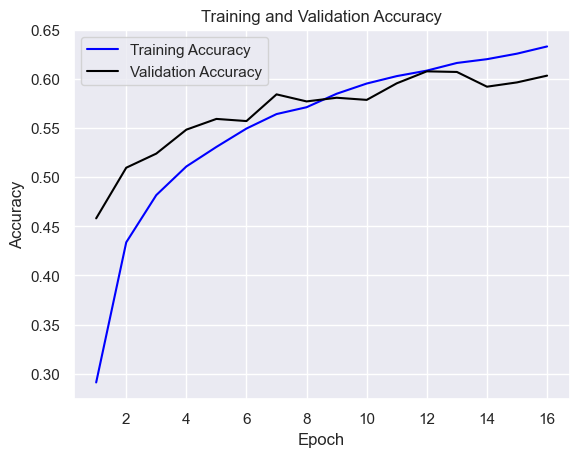

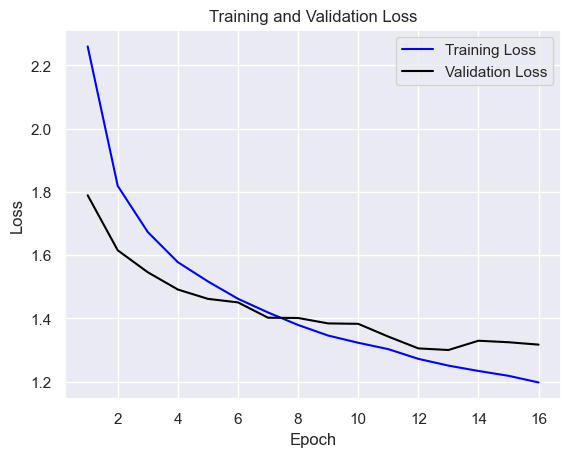

In [113]:
#plotting training values
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

#accuracy plot
plt.plot(epochs, acc, color='blue', label='Training Accuracy')
plt.plot(epochs, val_acc, color='black', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.figure()
#loss plot
plt.plot(epochs, loss, color='blue', label='Training Loss')
plt.plot(epochs, val_loss, color='black', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

plotting a heatmap of confusion matrix for better visualization

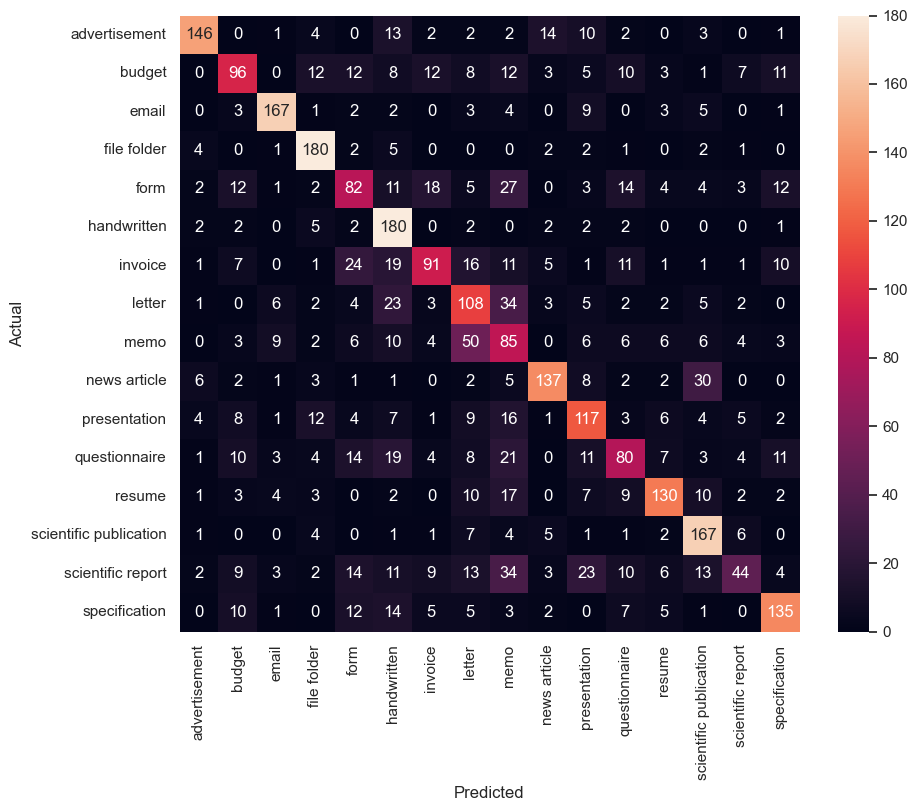

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Rows  and columns reprsent the actual class, Diagonal values reprsent correct predictions
and Off-diagonal values reprsent misclassifications